# sample3 - ニューラルネットワーク基礎（分類）

**nn.Module** を使ってニューラルネットワークを定義し、アイリスデータを分類します。  
PyTorch の学習ループ（forward → loss → backward → step）を体験します。

| ステップ | 内容 |
|----------|------|
| 1 | データ準備 |
| 2 | モデル定義（nn.Module） |
| 3 | 損失関数・オプティマイザ |
| 4 | 学習ループ |
| 5 | 評価・可視化 |

## 1. データ準備

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# データ読み込み
iris = load_iris()
X, y = iris.data, iris.target

# 前処理
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# NumPy → Tensor
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test,  dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test  = torch.tensor(y_test,  dtype=torch.long)

print("X_train:", X_train.shape, "y_train:", y_train.shape)

X_train: torch.Size([120, 4]) y_train: torch.Size([120])


## 2. モデル定義（nn.Module）

入力4次元 → 隠れ層16 → 隠れ層8 → 出力3クラス の全結合ネットワークです。

In [2]:
class IrisNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(4, 16)   # 入力4 → 隠れ層16
        self.fc2 = nn.Linear(16, 8)   # 隠れ層16 → 隠れ層8
        self.fc3 = nn.Linear(8, 3)    # 隠れ層8 → 出力3クラス
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)  # 出力層は活性化なし（CrossEntropyLoss が内部で処理）
        return x

model = IrisNet()
print(model)

IrisNet(
  (fc1): Linear(in_features=4, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=8, bias=True)
  (fc3): Linear(in_features=8, out_features=3, bias=True)
  (relu): ReLU()
)


## 3. 損失関数・オプティマイザ

In [3]:
criterion = nn.CrossEntropyLoss()                  # 多クラス分類の損失関数
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)  # Adam オプティマイザ
print("損失関数:", criterion)
print("オプティマイザ:", optimizer)

損失関数: CrossEntropyLoss()
オプティマイザ: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)


## 4. 学習ループ

PyTorch の学習は毎回この4ステップを繰り返します。
1. `forward` → 予測
2. `loss` → 誤差計算
3. `backward` → 勾配計算
4. `step` → パラメータ更新

In [4]:
epochs = 200
train_losses = []

for epoch in range(epochs):
    model.train()

    optimizer.zero_grad()          # 1. 勾配初期化
    output = model(X_train)        # 2. 順伝播（forward）
    loss = criterion(output, y_train)  # 3. 損失計算
    loss.backward()                # 4. 逆伝播（backward）
    optimizer.step()               # 5. パラメータ更新

    train_losses.append(loss.item())

    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] Loss: {loss.item():.4f}")

Epoch [50/200] Loss: 0.2880
Epoch [100/200] Loss: 0.1403
Epoch [150/200] Loss: 0.1006
Epoch [200/200] Loss: 0.0807


## 5. 評価・可視化

In [5]:
model.eval()
with torch.no_grad():
    output = model(X_test)
    predicted = torch.argmax(output, dim=1)
    accuracy = (predicted == y_test).float().mean()
    print(f"テスト正解率: {accuracy.item():.4f}")

テスト正解率: 1.0000


/tmp/ipykernel_49851/2712166393.py:7: UserWarning: Glyph 23398 (\N{CJK UNIFIED IDEOGRAPH-5B66}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_49851/2712166393.py:7: UserWarning: Glyph 32722 (\N{CJK UNIFIED IDEOGRAPH-7FD2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_49851/2712166393.py:7: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_49851/2712166393.py:7: UserWarning: Glyph 32218 (\N{CJK UNIFIED IDEOGRAPH-7DDA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_49851/2712166393.py:7: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_49851/2712166393.py:7: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/user/HOME/sample/sample_python/402_PyTorch/env/lib/python3.12/site-packages/IPython/cor

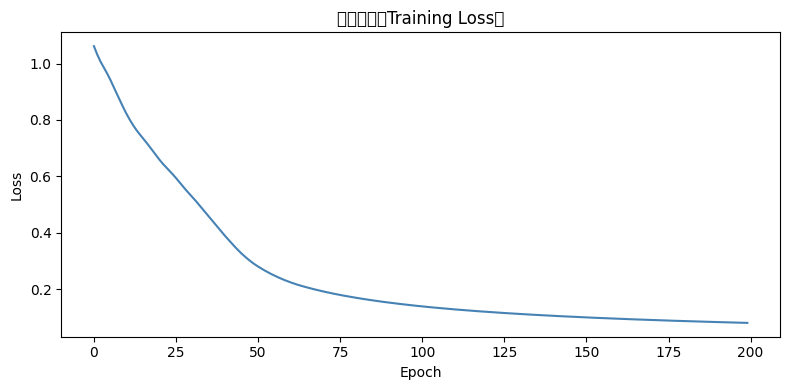

In [6]:
# Loss の推移
plt.figure(figsize=(8, 4))
plt.plot(train_losses, color='steelblue')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("学習曲線（Training Loss）")
plt.tight_layout()
plt.show()